# Ship engine anomaly detection

An exploratory data science project completed by Alex DiDonato for the Cambridge Data Science Career Accelerator. The course supplied the dataset and project brief; the analysis, code, visualisations and interpretation are my work.

The shipping business scenario is fictitious. The aim is to compare statistical screening and unsupervised methods for identifying unusual engine sensor observations that could warrant investigation.


## Project scope and context

The supplied data contains six numeric features: engine rpm, lubrication oil pressure, fuel pressure, coolant pressure, lubrication oil temperature and coolant temperature. The course download URL and original dataset reference are documented below.

The **1–5% anomaly range is an assignment assumption**, not measured fault prevalence. Parameters are explored in relation to this range, rather than validated against fault labels. Flagged observations are **candidate anomalies requiring investigation**.

This is exploratory analysis: preprocessing, model fitting, parameter selection and inspection use the same dataset. Generalisation to new observations has not been evaluated. Model agreement and PCA plots cannot establish detection accuracy.


## Analysis overview

We inspect data quality and distributions, apply IQR screening, explore One-Class SVM and Isolation Forest settings, and compare their candidate anomaly sets. Domain review and independently labelled observations would be needed to assess detection quality.


In [1]:
# Import the required libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from matplotlib_venn import venn2
from matplotlib_venn import venn3
import time

# Data Import

In [2]:
# URL to import data set from GitHub.
url = "https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv"
# Read the data.
ship_engine_data = pd.read_csv(url)

# View the 1st 5 rows
ship_engine_data.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


# Data Inspection

First we'll review the data and perform any data cleanse or pre-processing.

## Data Quality Checks

We will perform basic data quality checks, view the dataframe metadata to determine assigned datatypes, and determine the size of the dataset.

Data quality checks:

- Duplicated rows
- Missing data checks
- Trailing / Leading whitespace

In [3]:
# View the metadata with the info function.
ship_engine_data.info()

# Check for null values
print(
    "\nData quality check (1) detect null values in columns:\n"
    + str(ship_engine_data.isna().sum())
    + "\n"
)

# Check for duplicated rows
duplicated_rows = ship_engine_data.duplicated().sum()
print(
    "\nData quality check (2) count of duplicated rows: "
    + str(duplicated_rows)
)


<class 'pandas.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB

Data quality check (1) detect null values in columns:
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64


Data quality check (2) count of duplicated rows: 0



Initial data quality check show that there are no null values and all values are numeric, none of the 19535 rows are duplicated. Data types look appropriate for the data columns -- rpm (integer) - sensor readings (floats)

# Exploratory Data Analysis

Generate descriptive statistics and visualise the data to explore patterns, distributions, and trends in the data.

## Descriptive Statistics

We will now generate descriptive statistics for all columns in the dataset, and document any insights this provides about the data.

In [4]:
# Use df.describe to generate descriptive stats
ship_engine_data.describe(
    include="all", percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).T


,count,mean,std,min,5%,25%,50%,75%,95%,max
Engine rpm,19535.0,791.239263,267.611193,61.000000,443.000000,593.000000,746.000000,934.000000,1324.000000,2239.000000
Lub oil pressure,19535.0,3.303775,1.021643,0.003384,1.941852,2.518815,3.162035,4.055272,5.058040,7.265566
Fuel pressure,19535.0,6.655615,2.761021,0.003187,3.127162,4.916886,6.201720,7.744973,12.208475,21.138326
Coolant pressure,19535.0,2.335369,1.036382,0.002483,1.084493,1.600466,2.166883,2.848840,4.438415,7.478505
lub oil temp,19535.0,77.643420,3.110984,71.321974,74.269140,75.725990,76.817350,78.071691,84.940778,89.580796
Coolant temp,19535.0,78.427433,6.206749,61.673325,68.401196,73.895421,78.346662,82.915411,88.612891,195.527912


In [5]:
# Check the number of unique values in each column
ship_engine_data.nunique()


Engine rpm           1379
Lub oil pressure    19534
Fuel pressure       19531
Coolant pressure    19534
lub oil temp        19530
Coolant temp        19532
dtype: int64


**Feature Statistics Analysis**

All features apart from lub oil temp and Coolant temp show a right skewed distribution, with significant outliers.
<br></br>
*Engine rpm*

- Mean (791) > Median (746) -- suggesting that there is a slight right tail increasing the mean
- Max value of 2239 is well above the 95th percentile value (1324)<br><br>
Values cluster in the 600–900 range with large outliers inflating the mean.
This distribution is not symmetric.
<br>

*Lub oil pressure*

- Mean (3.30) > Median (3.16) -- the distribution has a slight right skew
- Max value of 7.27 is above the 95th percentile value (5.06)
<br>

*Fuel pressure*

- Mean (6.66) > Median (6.20) -- the distribution has positive skew
- Std deviation of 2.76 shows the data is diffuse
- Max value of 21.14 is above the 95th percentile value (12.21)
- Min is practically zero
<br>

*Coolant pressure*

- Mean (2.34) > Median (2.17) -- the distribution has heavy right skew
- Max value of 7.48 is above the 95th percentile value (4.44)
- Min is practically zero
<br>

*lub oil temp*

- Mean (77.64) very close to Median (76.82)
- Min and max values are close to the 5th and 95th percentile respectively
- Std deviation is small relative to the mean.


<br></br>

*Coolant temp*

- Mean (78.43) very close to Median (78.35)
- Max value is (195.53) is very high - over twice that of the 95th Percentile. Strong right-tail outliers.<br><br>
*NOTE:* The extreme coolant temperature is suspicious and requires investigation. Possible explanations include unusual operating conditions, measurement error or data processing issues. The dataset alone cannot confirm a sensor fault. We retain this observation pending domain review; its model flags are shown later and are not a test of accuracy.

- High Std deviation suggests the distribution is very diffuse
<br></br>

**Unique Values**

Unique values seen do not indicate data-quality issues.

Sensor features (Lub oil pressure, Fuel pressure, Coolant pressure, lub oil temp, Coolant temp) are continuous high-precision measurements and therefore show high uniqueness due to minor realtime fluctuations and float precision - this does not indicate a data-quality issue.

Engine rpm shows a lower range of unique values (1379) which is expected RPM is a discrete measurement and an engine will typically operate at a stable rpm value instead of constantly moving through the full observed range (61 to 2239)


## Visualise the data

We will now visualise the data with box-plots and histograms to further understand the data patterns, distributions, and trends

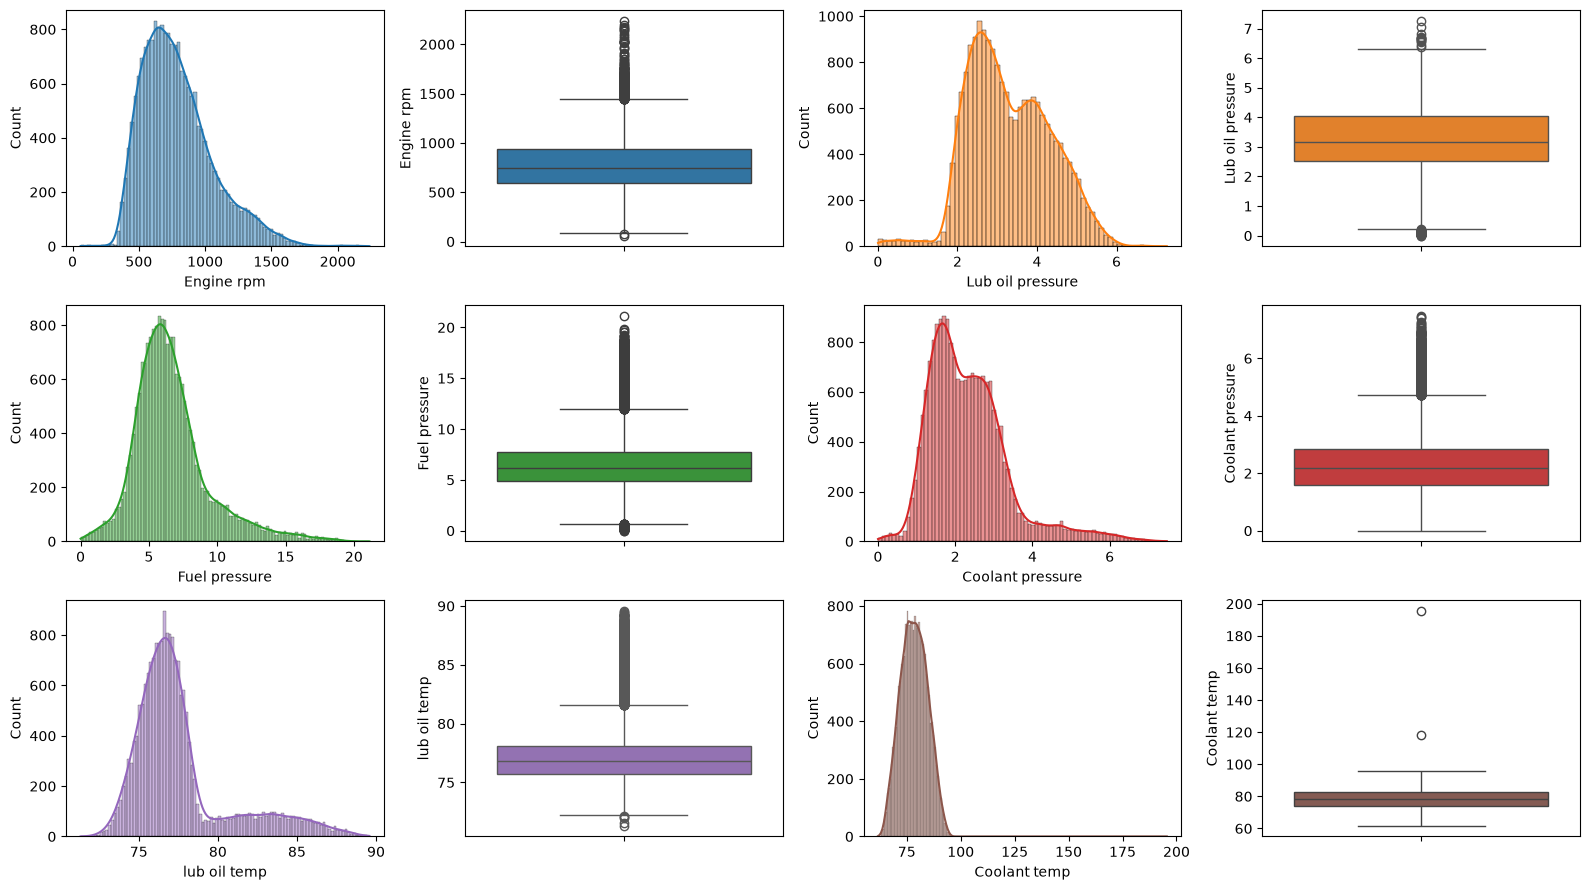

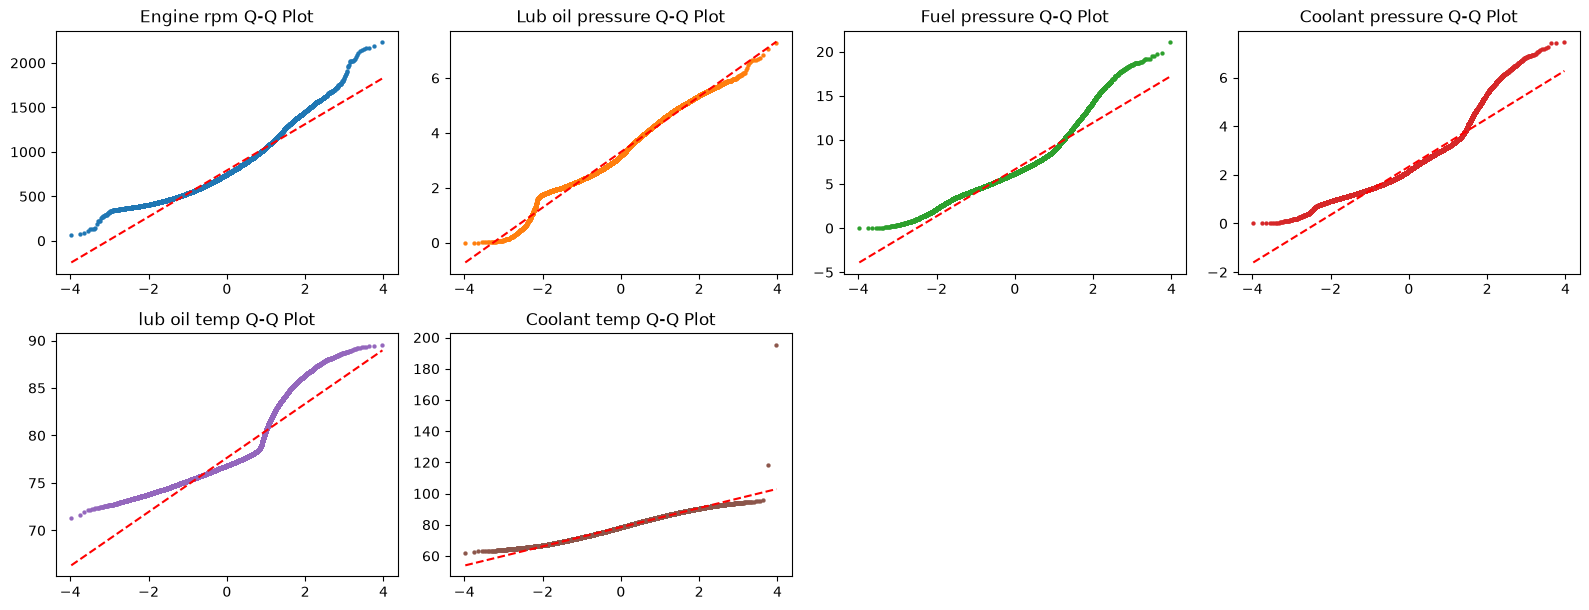

In [6]:
# Function to add histogram subplot
def add_histogram_subplot(ax, values, color="blue", title=None):
    sns.histplot(values, kde=True, color=color, ax=ax)
    ax.set_title(title)


# Function to add boxplot subplot
def add_boxplot_subplot(ax, values, color="blue", title=None):
    sns.boxplot(values, color=color, ax=ax)
    ax.set_title(title)


# Function to add scatterplot subplot
def add_scatterplot_subplot(ax, x_values, y_values, color="blue", title=None):
    sns.scatterplot(
        x=x_values, y=y_values, color=color, ax=ax, edgecolor=None, s=8
    )
    ax.set_title(title)


# Function to add line to subplot
def add_line_subplot(
    ax, x_values, y_values, color="blue", title=None, linestyle="-"
):
    sns.lineplot(
        x=x_values, y=y_values, color=color, ax=ax, linestyle=linestyle
    )
    ax.set_title(title)


# choose columns to plot - exclude categorical columns
cols = ship_engine_data.columns

# number of plots / cols (we will be creating 2 plots per column)
n = len(cols) * 2
ncols = 4
nrows = math.ceil(n / ncols)

# create subplots
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.ravel()  # flatten

cmap = plt.colormaps.get_cmap("tab10")  # get the colormap

# add histograms to subplots
for i, col in enumerate(cols):
    add_histogram_subplot(axes[(2 * i)], ship_engine_data[col], cmap(i % 20))
    add_boxplot_subplot(axes[(2 * i) + 1], ship_engine_data[col], cmap(i % 20))

# hide any unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

n = len(cols)  # we will be creating only 1 plot per column

# Q-Q plot for normality check
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.ravel()  # flatten

for i, col in enumerate(cols):
    # use probplot to get the theoretical and ordered values - also get slope, intercept, r
    (theoretical, ordered), (slope, intercept, r) = stats.probplot(
        ship_engine_data[col].to_numpy(), dist="norm", plot=None
    )
    ax = axes[i]

    # use scatter plot for Q-Q so that we can color the points
    add_scatterplot_subplot(ax, theoretical, ordered, cmap(i % 20))
    # Plot the theoretical line
    add_line_subplot(
        ax,
        theoretical,
        slope * theoretical + intercept,
        color="red",
        linestyle="--",
    )

    ax.set_title(col + " Q-Q Plot")

# hide any unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### Interpretation

**Distribution**

None of these features appears normally distributed, and all sensor variables (Lub oil pressure, Fuel pressure, Coolant pressure, lub oil temp, Coolant temp) show clear departures from normality - suggested by histograms and Q-Q plots.

Distributions are generally right skewed, and in some cases multimodal - this could indicate different engine operating states.
<br><br>
**Outliers and Data Quality Observations**

All pressure variables show numerous high-end outliers, and near-zero readings in pressure variables are present.

Coolant temperature contains at least one extreme high value.

RPM shows both high and low extremes, which may reflect distinct operating points.

Oil temperature also exhibits numerous high-end outliers, although none above 95 degrees whose operating significance requires domain confirmation.

Some of the extreme outlier values should be flagged for further verification with the domain expert - a coolant temperature of 195 degrees for example is extremely high and could signify a sensor error.

# Anomaly Detection

We will now apply several anomaly-detection methods to the data-set and observe the results.

## Interquartile Range (IQR)

We can use the IQR method to identify outliers on a per feature basis. Data points for each feature will be flagged as an outlier when the value falls outside following bounds:

- Lower range limit = $Q_1 - 1.5 \times \mathrm{IQR}$
- Higher range limit = $Q_3 + 1.5 \times \mathrm{IQR}$

where $Q_1$ and $Q_3$ are the 25th and 75th percentile, and $IQR = Q_3$ - $Q_1$ for the feature in question.

We will identify which values are IQR outliers for each individual feature and then analyse the number of features in a given sample flagged as outliers with respect to the total number of samples in the dataset.


In [7]:
def get_iqr_outlier_flags(df, suffix="_flagged"):
    """
    This function identifies outliers in numeric columns of a DataFrame using
    the IQR method.
    """

    # Select only numeric columns (in this case all columns are numeric)
    numeric_cols = df.select_dtypes(include="number").columns

    if len(numeric_cols) == 0:
        raise ValueError("No numeric columns found for IQR outlier detection.")

    # Calculate IQR for each numeric column (output is a series)
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Create a summary DataFrame
    summary = pd.concat(
        [Q1, Q3, IQR, lower, upper],
        axis=1,
        keys=["Q1", "Q3", "IQR", "lower", "upper"],
    )

    # return the outlier flags
    return (
        df[numeric_cols].lt(lower, axis="columns")
        | df[numeric_cols].gt(upper, axis="columns")
    ).add_suffix(suffix), summary


# Call the function to get outlier flags
outlier_flags, IQR_summary = get_iqr_outlier_flags(ship_engine_data)

# Concatenate back to original dataframe, converting boolean to int
ship_engine_data_with_outliers = pd.concat(
    [ship_engine_data, outlier_flags.astype(int)], axis=1
)

print("\nIQR Summary Statistics:\n", IQR_summary, "\n")

# view the new dataframe with outlier flags
ship_engine_data_with_outliers.head()



IQR Summary Statistics:
                           Q1          Q3         IQR      lower        upper
Engine rpm        593.000000  934.000000  341.000000  81.500000  1445.500000
Lub oil pressure    2.518815    4.055272    1.536457   0.214130     6.359957
Fuel pressure       4.916886    7.744973    2.828087   0.674755    11.987104
Coolant pressure    1.600466    2.848840    1.248374  -0.272095     4.721400
lub oil temp       75.725990   78.071691    2.345700  72.207440    81.590241
Coolant temp       73.895421   82.915411    9.019990  60.365435    96.445397 



,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_flagged,Lub oil pressure_flagged,Fuel pressure_flagged,Coolant pressure_flagged,lub oil temp_flagged,Coolant temp_flagged
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0


In [8]:
# Determine the number of outliers per row
ship_engine_data_with_outliers["outlier_count"] = (
    ship_engine_data_with_outliers.filter(like="_flagged").sum(axis=1)
)

# view the new dataframe with outlier counts where outlier count > 1
ship_engine_data_with_outliers[
    ship_engine_data_with_outliers["outlier_count"] > 1
].head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_flagged,Lub oil pressure_flagged,Fuel pressure_flagged,Coolant pressure_flagged,lub oil temp_flagged,Coolant temp_flagged,outlier_count
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,1,0,0,0,1,0,2
122,1454,2.063374,6.168260,1.260121,83.372256,82.718247,1,0,0,0,1,0,2
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,0,0,1,0,1,0,2
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,1,0,0,0,1,0,2
148,1494,2.443220,3.548139,1.953403,82.234541,83.953914,1,0,0,0,1,0,2


In [9]:
# Print the count and percentage of rows with different numbers of outliers
total_rows = ship_engine_data_with_outliers.shape[0]

for i in range(
    1, len(ship_engine_data_with_outliers.filter(like="_flagged").columns) + 1
):
    count = (ship_engine_data_with_outliers["outlier_count"] == i).sum()
    cumulative_count = (
        ship_engine_data_with_outliers["outlier_count"] >= i
    ).sum()
    print(
        f"Rows with exactly {i} IQR-flagged features:"
        f" {count} ({(count / total_rows) * 100:.2f}%), Rows with at least "
        f"{i} IQR-flagged features: {cumulative_count} "
        f"({(cumulative_count / total_rows) * 100:.2f}%) "
    )

Rows with exactly 1 IQR-flagged features: 4214 (21.57%), Rows with at least 1 IQR-flagged features: 4636 (23.73%) 
Rows with exactly 2 IQR-flagged features: 411 (2.10%), Rows with at least 2 IQR-flagged features: 422 (2.16%) 
Rows with exactly 3 IQR-flagged features: 11 (0.06%), Rows with at least 3 IQR-flagged features: 11 (0.06%) 
Rows with exactly 4 IQR-flagged features: 0 (0.00%), Rows with at least 4 IQR-flagged features: 0 (0.00%) 
Rows with exactly 5 IQR-flagged features: 0 (0.00%), Rows with at least 5 IQR-flagged features: 0 (0.00%) 
Rows with exactly 6 IQR-flagged features: 0 (0.00%), Rows with at least 6 IQR-flagged features: 0 (0.00%) 


## IQR interpretation

The executed output above distinguishes **exactly N** flagged features from **at least N**. We select at least two IQR-flagged features as the row-level screening rule because its flag rate falls within the assignment's assumed 1–5% range. This is a screening choice, not evidence of true fault prevalence.

IQR provides simple, readable univariate thresholds. It does not model feature interactions, and skewed or multimodal distributions affect its interpretation. A row with just one flagged feature can still merit investigation; the selected rule does not establish which observations are safe or faulty.


## One-Class SVM

We will explore using One-class SVM for anomaly detection.

### Scaling and Dimensionality Reduction

Prior to running One-class SVM we must scale the dataset as One-Class SVM is distance-based - without scaling features with large numeric ranges will dominate.

We will also run dimensionality reduction using PCA - this is required to allow us to visualise the data in 2 dimensions - PCA is also sensitive to feature magnitude as it is variance based, so we must standardise the features prior to dimensionality reduction.

In [10]:
# standardise the data using standard scaling (z-score normalisation)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    data=scaler.fit_transform(ship_engine_data),
    columns=ship_engine_data.columns,
)

X_scaled.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491


### Explore One-Class SVM Parameter Settings

The initial objective is to train a One-Class SVM on the scaled 6D dataset and experiment with parameter settings such that the model is tuned to an anomaly rate consistent with the assignment assumption of 1–5%.

We explore the two key One-Class SVM hyperparameters:

- ν (nu): upper bound on the fraction of training errors (subject to numerical tolerance) and lower bound on the fraction of support vectors
- γ (gamma): kernel coefficient controlling decision boundary tightness



In [11]:
# function to create One-Class SVM model and return predictions
def OneClassSVM_model(X_scaled, gamma=0.05, nu=0.03):
    model = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu)
    model.fit(X_scaled)
    y_pred = model.predict(X_scaled)
    return y_pred


# Test different gamma and nu values and print number of anomalies detected
params = (
    {"gamma": 1.0, "nu": 0.05},
    {"gamma": 1.0, "nu": 0.03},
    {"gamma": 1.0, "nu": 0.01},
    {"gamma": 0.5, "nu": 0.05},
    {"gamma": 0.5, "nu": 0.03},
    {"gamma": 0.5, "nu": 0.01},
    {"gamma": 0.1, "nu": 0.05},
    {"gamma": 0.1, "nu": 0.03},
    {"gamma": 0.1, "nu": 0.01},
    {"gamma": 0.05, "nu": 0.05},
    {"gamma": 0.05, "nu": 0.03},
    {"gamma": 0.05, "nu": 0.02},
    {"gamma": 0.01, "nu": 0.01},
    {"gamma": 0.01, "nu": 0.03},
)

# Iterate through parameter combinations and print number of anomalies detected
for p in params:
    start = time.perf_counter()
    y_pred = OneClassSVM_model(X_scaled, p["gamma"], p["nu"])
    n_anomalies = (y_pred == -1).sum()
    elapsed = time.perf_counter() - start
    print(
        f"One-Class SVM with gamma={p['gamma']}, nu={p['nu']} detected"
        f" {n_anomalies} anomalies. ({(n_anomalies / total_rows) * 100:.2f}%)"
        f", Time taken: "
        f"{elapsed * 1000:.0f} milliseconds"
    )



One-Class SVM with gamma=1.0, nu=0.05 detected 1861 anomalies. (9.53%), Time taken: 5058 milliseconds


One-Class SVM with gamma=1.0, nu=0.03 detected 1859 anomalies. (9.52%), Time taken: 4876 milliseconds


One-Class SVM with gamma=1.0, nu=0.01 detected 1932 anomalies. (9.89%), Time taken: 4431 milliseconds


One-Class SVM with gamma=0.5, nu=0.05 detected 1043 anomalies. (5.34%), Time taken: 1614 milliseconds


One-Class SVM with gamma=0.5, nu=0.03 detected 737 anomalies. (3.77%), Time taken: 1355 milliseconds


...

One-Class SVM with gamma=0.05, nu=0.05 detected 978 anomalies. (5.01%), Time taken: 1097 milliseconds


One-Class SVM with gamma=0.05, nu=0.03 detected 583 anomalies. (2.98%), Time taken: 680 milliseconds


One-Class SVM with gamma=0.05, nu=0.02 detected 395 anomalies. (2.02%), Time taken: 460 milliseconds


One-Class SVM with gamma=0.01, nu=0.01 detected 197 anomalies. (1.01%), Time taken: 237 milliseconds


One-Class SVM with gamma=0.01, nu=0.03 detected 586 anomalies. (3.00%), Time taken: 681 milliseconds


**Interpretation**

The executed parameter experiment above reports candidate counts and elapsed times. High gamma settings produce higher flag rates in this dataset. Matching the assignment's 1–5% assumption does not validate any setting, and counts alone cannot identify the best detector.

### Chosen model settings

We retain **gamma = 0.05** and **nu = 0.03** as exploratory settings for comparison. They yield a flag rate within the assignment range and are practical to inspect. Domain review and independent evaluation are needed before recommending them for operational use.


### Compare to IQR method

We can append the outputs of the model to the dataframe with the IQR outliers to determine if there is any overlap between the One-Class SVM model outliers and IQR outliers.

A 2x2 heatmap will provide a useful visualisation.

In [12]:
# create the chosen model
model = OneClassSVM(kernel="rbf", gamma=0.05, nu=0.03)
model.fit(X_scaled)
y_pred = model.predict(X_scaled)

# add the One-Class SVM Outliers to the outlier dataframe
ship_engine_data_with_outliers["One-Class_SVM_Outliers"] = y_pred

# view the top 5 rows of data
ship_engine_data_with_outliers.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_flagged,Lub oil pressure_flagged,Fuel pressure_flagged,Coolant pressure_flagged,lub oil temp_flagged,Coolant temp_flagged,outlier_count,One-Class_SVM_Outliers
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1,-1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0,1


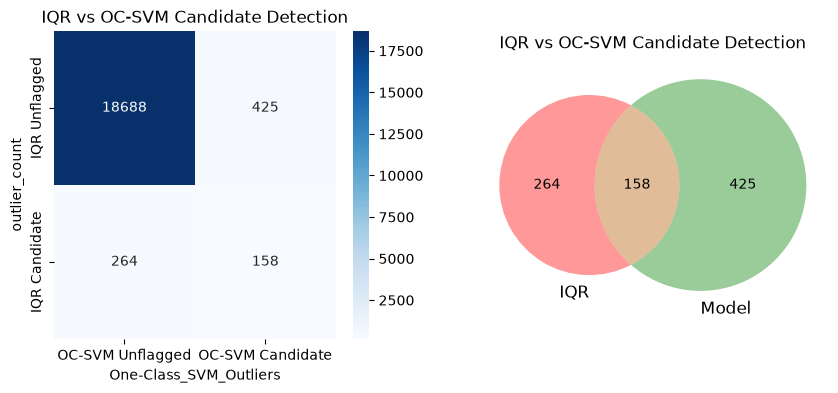

In [13]:
# get a list of IQR outlier flags (where # of outliers in individual features >=2 )
iqr_flags = (ship_engine_data_with_outliers["outlier_count"] >= 2).astype(int)
# get a list of One-Class_SVM Outlier flags (where value = -1)
model_flags = (
    ship_engine_data_with_outliers["One-Class_SVM_Outliers"] == -1
).astype(int)
# create agreement table
cm = pd.crosstab(iqr_flags, model_flags).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

# plot agreement table and venn diagram
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.ravel()  # flatten

ax = axes[0]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["OC-SVM Unflagged", "OC-SVM Candidate"],
    yticklabels=["IQR Unflagged", "IQR Candidate"],
    ax=ax,
)
ax.set_title("IQR vs OC-SVM Candidate Detection")

set_iqr = set(np.where(iqr_flags == 1)[0])
set_model = set(np.where(model_flags == 1)[0])

ax = axes[1]

venn2([set_iqr, set_model], ("IQR", "Model"), ax=ax)
ax.set_title("IQR vs OC-SVM Candidate Detection")
plt.show()

**Interpretation**

The heatmap is a pairwise **agreement table**, not evaluation against ground truth. Neither method supplies verified labels. Most observations are unflagged by both methods, while their candidate sets differ. IQR uses individual feature thresholds and One-Class SVM uses a multivariate boundary; overlap alone cannot establish accuracy or superiority.


### Visualising model output – chosen settings

PCA reduces the standardised six-feature data to two components for visual exploration. Predictions are made in the full feature space and then coloured on the projection. Information is lost in this projection, so apparent separation or similar plots cannot establish detection accuracy or equivalent model performance.


In [14]:
# Plot full-feature model flags on a two-component PCA projection
def plot_model_projection(model, X, X_2d, title, y_pred=None):
    # Predictions in model space (high-D)
    if y_pred is None:
        y_pred = model.predict(X)

    # create plot
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.title(title)

    accepted = y_pred == 1
    rejected = y_pred == -1

    accepted_pct = 100.0 * accepted.mean()
    rejected_pct = 100.0 * rejected.mean()

    # use matplotlib's scatter to plot the points (allows better layering)
    ax.scatter(
        X_2d[rejected, 0],
        X_2d[rejected, 1],
        s=14,
        marker="X",
        linewidths=0.6,
        c="darkred",
        alpha=0.8,
        label=f"Candidate anomaly ({rejected_pct:.1f}%)",
        zorder=3,
    )
    ax.scatter(
        X_2d[accepted, 0],
        X_2d[accepted, 1],
        s=12,
        marker="o",
        c="deepskyblue",
        alpha=0.40,
        edgecolors="#1f4f6f",  # very muted blue-grey
        linewidths=0.2,  # thin outline
        label=f"Unflagged ({accepted_pct:.1f}%)",
        zorder=2,
    )

    ax.legend(title="Model flag")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    plt.axis("tight")
    plt.show()


Variance explained: PC1=18.99%, PC2=17.69%, combined=36.69%


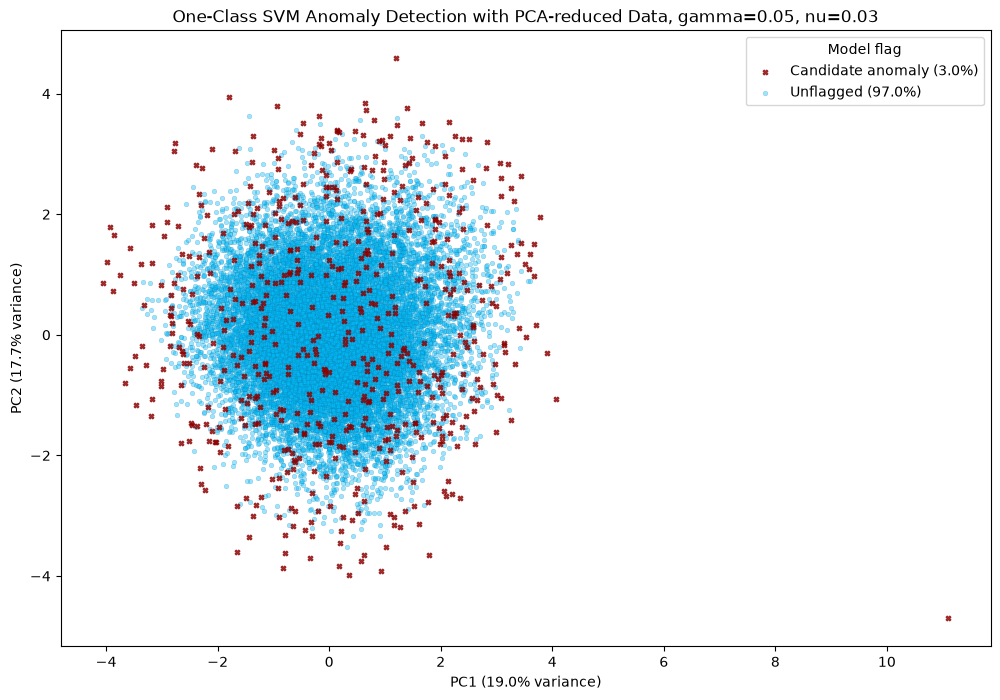

In [15]:
# Fit PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}, "
      f"combined={pca.explained_variance_ratio_.sum():.2%}")

# Plot the model projection
plot_model_projection(
    model,
    X_scaled.to_numpy(),
    X_2d,
    title="One-Class SVM Anomaly Detection with PCA-reduced Data" \
    ", gamma=0.05, nu=0.03",
    y_pred=y_pred
)


Candidate anomalies are scattered across the PCA projection. A full six-dimensional decision boundary cannot be inferred from this plot. The suspicious coolant-temperature observation is inspected directly in the final summary below. A flag on that observation would indicate model sensitivity, not a confirmed fault or correct classification.


## Isolation Forest

We will next explore using a different method for anomaly detection - Isolation Forest.

We do not need to scale data when using isolation forest as it is a tree based method.

### Explore Model Settings for Outlier Detection

First we try combinations of model settings using the original unscaled dataset to understand the effect on the number of outliers. We will adjust:

- Contamination (this should set the anomaly detection rate)
- n_estimators (the number of trees the model uses)

Note: the assignment assumes an anomaly range of 1–5%, not measured prevalence, so an appropriate contamination rate will be between 0.01 and 0.05

In [16]:
# Function to create an Isolation Forest model and return predictions
def IsolationForest_model(
    X, n_estimators=100, contamination=0.05, random_state=42
):
    iso_forest = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
    )
    iso_forest.fit(X)
    y_pred = iso_forest.predict(X)
    return y_pred


# Test different tree counts and contamination values and print number of anomalies detected
params = (
    {"n_estimators": 50, "contamination": 0.05},
    {"n_estimators": 100, "contamination": 0.05},
    {"n_estimators": 200, "contamination": 0.05},
    {"n_estimators": 500, "contamination": 0.05},
    {"n_estimators": 1000, "contamination": 0.05},
    {"n_estimators": 5000, "contamination": 0.05},
    {"n_estimators": 50, "contamination": 0.01},
    {"n_estimators": 100, "contamination": 0.01},
    {"n_estimators": 200, "contamination": 0.01},
    {"n_estimators": 500, "contamination": 0.01},
    {"n_estimators": 1000, "contamination": 0.01},
    {"n_estimators": 5000, "contamination": 0.01},
    {"n_estimators": 50, "contamination": 0.03},
    {"n_estimators": 100, "contamination": 0.03},
    {"n_estimators": 200, "contamination": 0.03},
    {"n_estimators": 500, "contamination": 0.03},
    {"n_estimators": 1000, "contamination": 0.03},
    {"n_estimators": 5000, "contamination": 0.03},
    {"n_estimators": 200, "contamination": 0.1},
    {"n_estimators": 200, "contamination": 0.04},
    {"n_estimators": 200, "contamination": 0.03},
    {"n_estimators": 200, "contamination": 0.02},
)

# Iterate through parameter combinations and print number of anomalies detected
for p in params:
    start = time.perf_counter()
    y_pred = IsolationForest_model(
        ship_engine_data, p["n_estimators"], p["contamination"]
    )
    elapsed = time.perf_counter() - start
    n_anomalies = (y_pred == -1).sum()
    print(
        f"Isolation Forest with n_estimators={p['n_estimators']}"
        f", contamination="
        f"{p['contamination']} detected {n_anomalies} anomalies. ("
        f"{(n_anomalies / total_rows) * 100:.2f}%), Time taken: "
        f"{elapsed * 1000:.0f} milliseconds"
    )


Isolation Forest with n_estimators=50, contamination=0.05 detected 977 anomalies. (5.00%), Time taken: 110 milliseconds


Isolation Forest with n_estimators=100, contamination=0.05 detected 977 anomalies. (5.00%), Time taken: 214 milliseconds


Isolation Forest with n_estimators=200, contamination=0.05 detected 977 anomalies. (5.00%), Time taken: 422 milliseconds


Isolation Forest with n_estimators=500, contamination=0.05 detected 977 anomalies. (5.00%), Time taken: 1046 milliseconds


Isolation Forest with n_estimators=1000, contamination=0.05 detected 977 anomalies. (5.00%), Time taken: 2065 milliseconds


...

Isolation Forest with n_estimators=5000, contamination=0.03 detected 587 anomalies. (3.00%), Time taken: 10361 milliseconds


Isolation Forest with n_estimators=200, contamination=0.1 detected 1954 anomalies. (10.00%), Time taken: 428 milliseconds


Isolation Forest with n_estimators=200, contamination=0.04 detected 782 anomalies. (4.00%), Time taken: 434 milliseconds


Isolation Forest with n_estimators=200, contamination=0.03 detected 587 anomalies. (3.00%), Time taken: 447 milliseconds


Isolation Forest with n_estimators=200, contamination=0.02 detected 391 anomalies. (2.00%), Time taken: 425 milliseconds


The executed experiment above records counts and runtime for each setting. Contamination controls the approximate fraction flagged on the fitted dataset, subject to rounding and tied scores; it does not estimate fault prevalence. Changing tree count can change which observations are flagged even when the total count stays the same.

Larger forests take longer to fit and inspect. Counts alone cannot establish detection quality or an optimal number of trees. We retain 3% contamination as an exploratory choice within the assignment range.


### Explore Isolation Forest estimator Settings (After 2D PCA)

We will now visualise the model outputs in a scatter plot using a 2D PCA reduced feature set (PC1, PC2, coloured by y_pred from the full model), and try different settings of n_estimators to understand the effect of the setting on the projected candidate distribution.

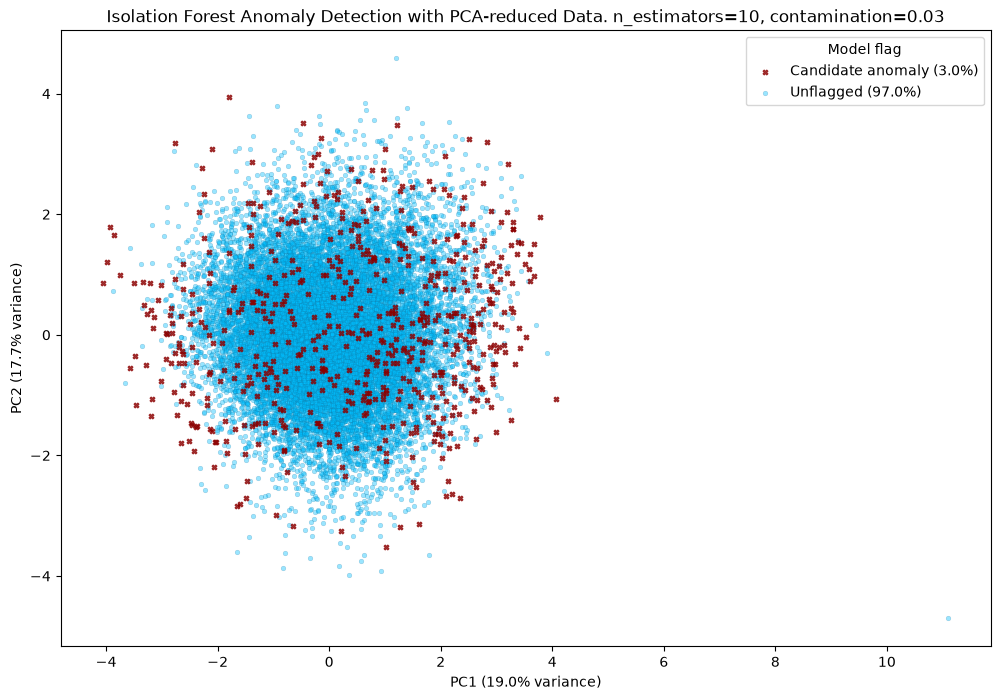

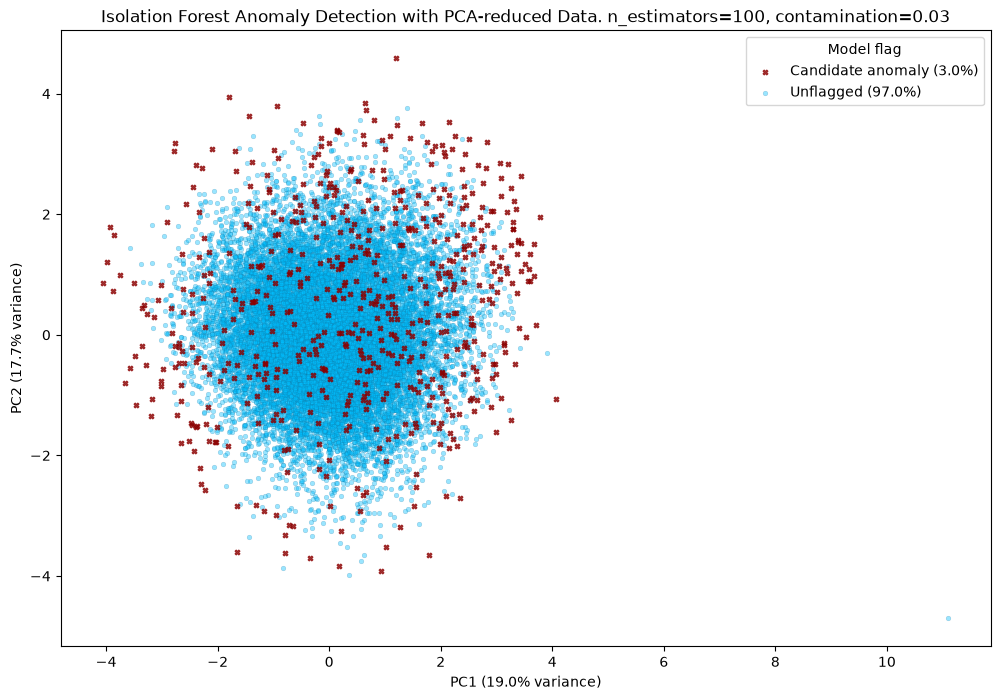

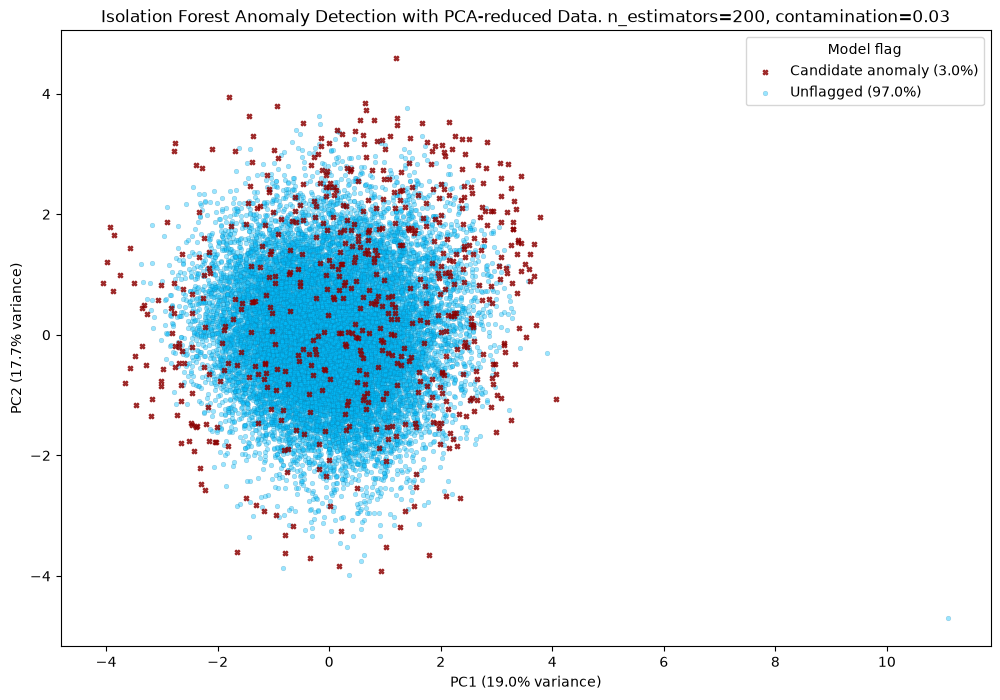

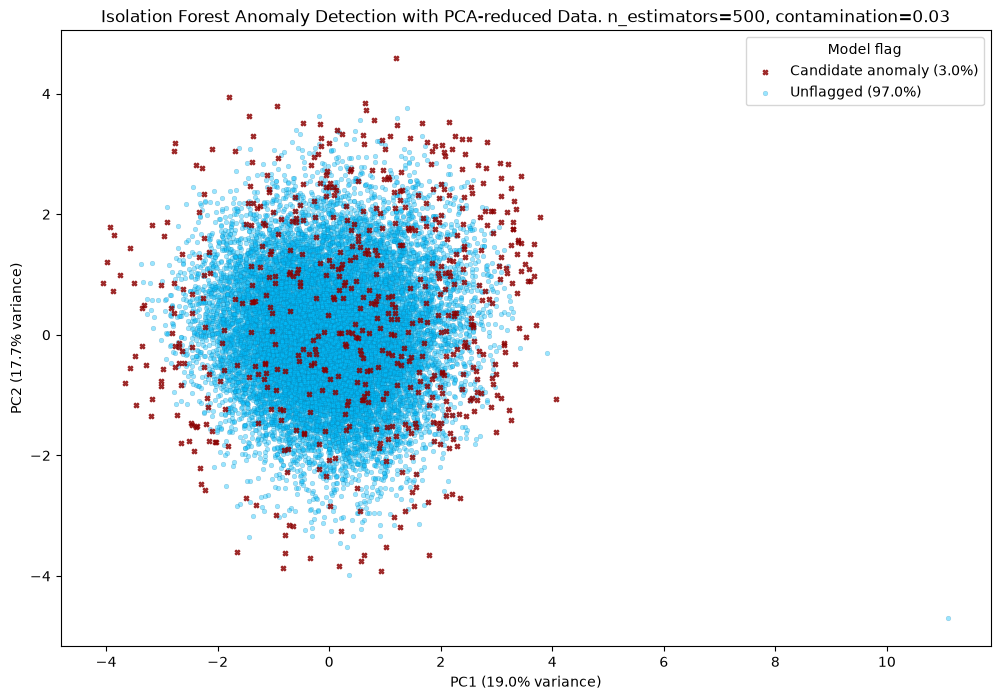

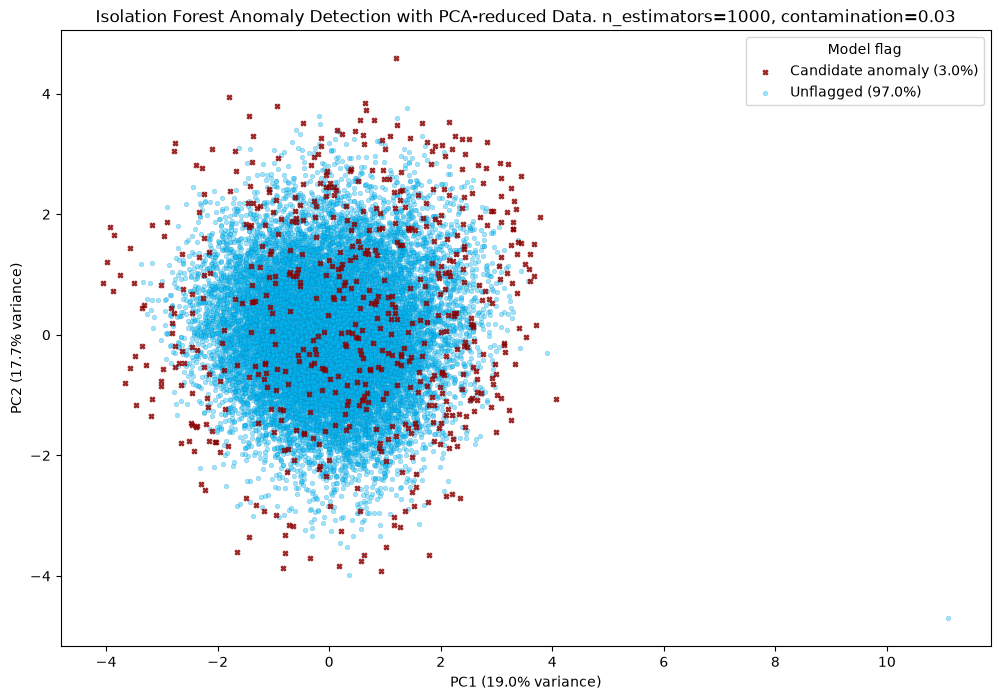

In [17]:
# Test different tree counts and contamination values and print number of anomalies detected
params = (
    {"n_estimators": 10, "contamination": 0.03},
    {"n_estimators": 100, "contamination": 0.03},
    {"n_estimators": 200, "contamination": 0.03},
    {"n_estimators": 500, "contamination": 0.03},
    {"n_estimators": 1000, "contamination": 0.03},
)

# Iterate through parameter combinations and print number of anomalies detected
for p in params:
    y_pred = IsolationForest_model(
        ship_engine_data, p["n_estimators"], p["contamination"]
    )
    plot_model_projection(
        None,
        ship_engine_data,
        X_2d,
        title="Isolation Forest Anomaly Detection with "
        + "PCA-reduced Data. n_estimators="
        + str(p["n_estimators"])
        + ", contamination="
        + str(p["contamination"]),
        y_pred=y_pred,
    )

### Chosen model settings

We select **n_estimators = 200**, **contamination = 0.03**, retaining **random_state = 42**. Other tree counts remain in the parameter experiments.

Several projected candidate distributions look similar, but this does not demonstrate equivalent performance, stability or accuracy. The choice of 200 trees is provisional, balancing observed runtime and practical simplicity. The suspicious coolant observation's flags are reported directly below; neither flagging nor leaving it unflagged establishes whether it is faulty.


### Comparison to IQR and One-Class SVM

We can append the outputs of the model to the dataframe with the IQR and OC-SVM outliers to determine if there is any overlap between the three methods.

A 2x2 heatmap will provide a useful visualisation.

In [18]:
# create the chosen model
y_pred = IsolationForest_model(ship_engine_data, 200, 0.03)

# add the Isolation Forest flags to the outlier dataframe
ship_engine_data_with_outliers["Isolation_Forest_Outliers"] = y_pred

# view the top 5 rows of data
ship_engine_data_with_outliers.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_flagged,Lub oil pressure_flagged,Fuel pressure_flagged,Coolant pressure_flagged,lub oil temp_flagged,Coolant temp_flagged,outlier_count,One-Class_SVM_Outliers,Isolation_Forest_Outliers
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0,1,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1,-1,-1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1,1,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0,1,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0,1,1


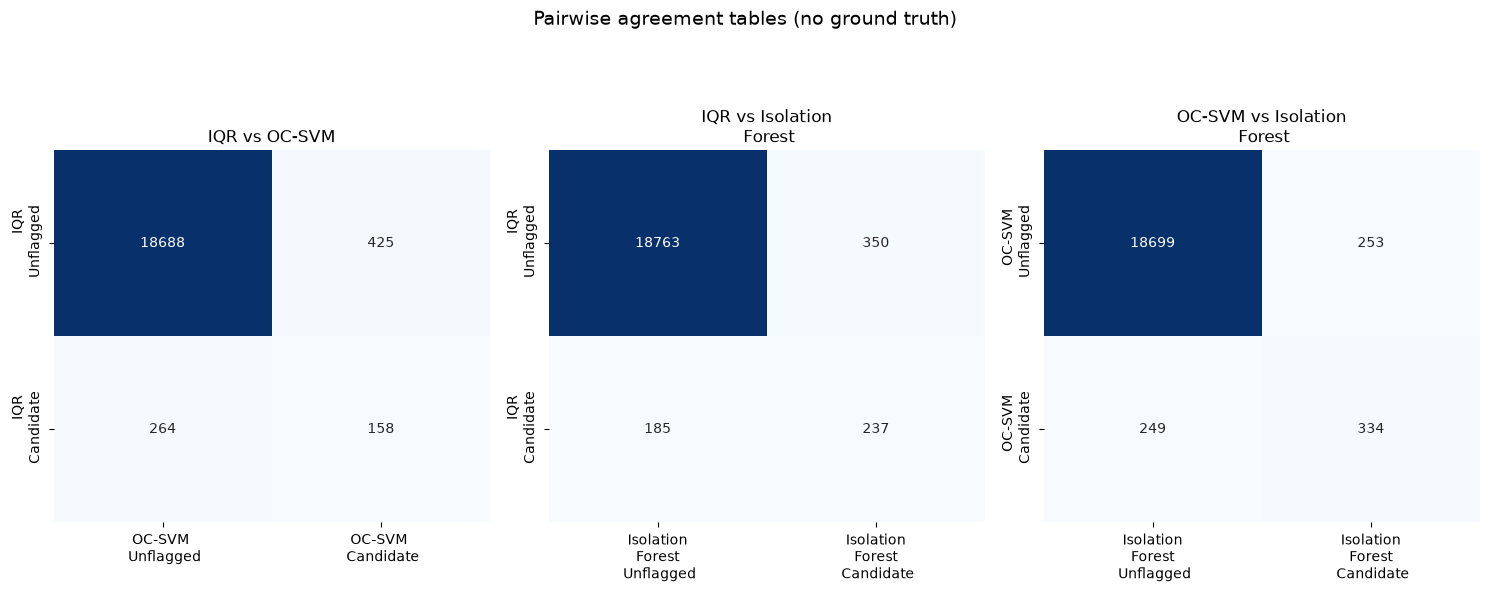

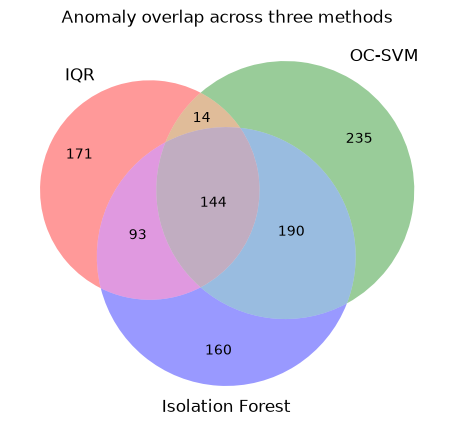

Final candidate counts:
IQR (at least 2): 422 (2.16%)
One-Class SVM: 583 (2.98%)
Isolation Forest (200 trees): 587 (3.00%)
IQR / OC-SVM overlap: 158
IQR / Isolation Forest overlap: 237
OC-SVM / Isolation Forest overlap: 334
All three methods: 144
Suspicious maximum coolant-temperature observation and flags:
Engine rpm                   455.000000
Lub oil pressure               2.010802
Fuel pressure                  7.806127
Coolant pressure               1.619575
lub oil temp                  76.519385
Coolant temp                 195.527912
Engine rpm_flagged             0.000000
Lub oil pressure_flagged       0.000000
Fuel pressure_flagged          0.000000
Coolant pressure_flagged       0.000000
lub oil temp_flagged           0.000000
Coolant temp_flagged           1.000000
outlier_count                  1.000000
One-Class_SVM_Outliers        -1.000000
Isolation_Forest_Outliers      1.000000
Name: 10663, dtype: float64


In [19]:
# Flags (1 = anomaly, 0 = normal)
iqr_flags = (
    (ship_engine_data_with_outliers["outlier_count"] >= 2)
    .astype(int)
    .to_numpy()
)
OC_SVM_model_flags = (
    (ship_engine_data_with_outliers["One-Class_SVM_Outliers"] == -1)
    .astype(int)
    .to_numpy()
)
IF_model_flags = (
    (ship_engine_data_with_outliers["Isolation_Forest_Outliers"] == -1)
    .astype(int)
    .to_numpy()
)


def plot_agreement(ax, flags_a, flags_b, name_a, name_b):
    cm = pd.crosstab(flags_a, flags_b).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=[f"{name_b} \n Unflagged", f"{name_b} \n Candidate"],
        yticklabels=[f"{name_a} \n Unflagged", f"{name_a} \n Candidate"],
    )

    ax.set_title(f"{name_a} vs {name_b}")
    ax.set_xlabel("")
    ax.set_ylabel("")


fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# IQR vs OC-SVM
plot_agreement(axes[0], iqr_flags, OC_SVM_model_flags, "IQR", "OC-SVM")

# IQR vs Isolation Forest
plot_agreement(axes[1], iqr_flags, IF_model_flags, "IQR", "Isolation\n Forest")

# OC-SVM vs Isolation Forest
plot_agreement(
    axes[2], OC_SVM_model_flags, IF_model_flags, "OC-SVM", "Isolation\n Forest"
)

plt.suptitle("Pairwise agreement tables (no ground truth)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
set_iqr = set(np.where(iqr_flags == 1)[0])
set_oc = set(np.where(OC_SVM_model_flags == 1)[0])
set_if = set(np.where(IF_model_flags == 1)[0])

plt.figure(figsize=(6, 5))
venn3(
    [set_iqr, set_oc, set_if], set_labels=("IQR", "OC-SVM", "Isolation Forest")
)
plt.title("Anomaly overlap across three methods")
plt.show()

# Regenerate final counts, overlaps and the suspicious observation's flags.
print("Final candidate counts:")
for name, flags in [("IQR (at least 2)", iqr_flags), ("One-Class SVM", OC_SVM_model_flags), ("Isolation Forest (200 trees)", IF_model_flags)]:
    print(f"{name}: {flags.sum()} ({100 * flags.mean():.2f}%)")
print(f"IQR / OC-SVM overlap: {len(set_iqr & set_oc)}")
print(f"IQR / Isolation Forest overlap: {len(set_iqr & set_if)}")
print(f"OC-SVM / Isolation Forest overlap: {len(set_oc & set_if)}")
print(f"All three methods: {len(set_iqr & set_oc & set_if)}")
suspicious_index = ship_engine_data["Coolant temp"].idxmax()
print("Suspicious maximum coolant-temperature observation and flags:")
print(ship_engine_data_with_outliers.loc[suspicious_index])


**Interpretation**

The executed agreement tables and Venn diagram describe overlap between candidate sets. Large agreement on unflagged observations is expected when all methods flag a small minority. Shared flags can help prioritise investigation, but agreement does not prove true anomalies or detector superiority. Method-specific candidates also warrant review; without verified labels, false positives and missed faults cannot be counted.


# Approach and findings

We inspected completeness, duplicates, descriptive statistics and distributions, then compared IQR screening with One-Class SVM on standardised features and Isolation Forest on unscaled features. Parameters were explored against the assignment's assumed flag range. PCA supports visual inspection, while the agreement tables and Venn diagram describe differences between candidate sets. The executed summary above contains the final counts and overlaps.

## Limitations and provisional preference

All preprocessing, fitting, selection and inspection use the same dataset. There is no independent test set, verified fault ground truth or evaluation of generalisation to new observations. Flag rates are not fault prevalence, and neither agreement nor visual similarity establishes accuracy, superiority or equivalent performance.

IQR is a transparent screening rule but does not capture feature interactions. One-Class SVM requires scaling and its results depend on gamma and nu. Isolation Forest is practically simpler here, with a directly specified contamination setting. The parameter experiments record observed runtimes; they are single-run measurements on this machine, not rigorous benchmarks.

My provisional preference is **Isolation Forest with 200 trees and 3% contamination**, based on practical simplicity and the observed runtime tradeoff. This is not a claim of proven detection accuracy. The extreme coolant-temperature reading remains a suspicious observation requiring investigation, regardless of model agreement.

## Next steps

- Review both shared and method-specific candidates with an engine domain expert.
- Investigate suspicious sensor readings and establish operating limits and measurement provenance.
- Evaluate the selected settings on independent observations with verified outcomes before operational use.


# Dataset source

Course-supplied download: https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv

Original reference supplied in the project brief: Devabrat, M. (2022), *Predictive Maintenance on Ship's Main Engine using AI*. https://doi.org/10.21227/g3za-v415 (original notebook access date: 5 March 2024).

The downloaded course CSV contains six sensor features and no verified fault labels. The original reference is retained for attribution; its relationship to the course adaptation and redistribution permissions have not been independently verified. No dataset redistribution licence is asserted here.
